In [5]:
!pip install ultralytics
import torch
import cv2
import numpy as np
from ultralytics import YOLO
print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 70.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.4/75.4 kB 8.8 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
PyTorch version: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


In [3]:
!pip install roboflow
import os
from PIL import Image
import glob
from roboflow import Roboflow


rf = Roboflow(api_key="CwHmnjKUno0znmZamTBV")
project = rf.workspace("malakwalidabdelaal-gmail-com").project("wood-defect-detection-jvj8f-igeit")
version = project.version(2)
dataset = project.version(1).download("yolov11")

# 2. Resize Dataset Images on Disk to Reduce Memory Footprint
def resize_dataset_images(data_dir, target_size=(640, 640)):
    image_paths = glob.glob(f"{data_dir}/**/*.jpg", recursive=True) + \
                  glob.glob(f"{data_dir}/**/*.png", recursive=True)

    print(f"Resizing {len(image_paths)} images on disk to {target_size}...")
    for img_path in image_paths:
        with Image.open(img_path) as img:
            img_resized = img.resize(target_size, Image.Resampling.LANCZOS)
            img_resized.save(img_path, quality=85)
    print("Resizing complete.")


resize_dataset_images(dataset.location, target_size=(640, 640))

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Wood-defect-detection-1 in yolov11:: 100%|██████████| 20005/20005 [00:12<00:00, 1588.99it/s]


Resizing 10000 images on disk to (640, 640)...
Resizing complete.


In [4]:
import torch
from ultralytics import YOLO

def train_wood_model():

    model = YOLO("yolo11s-seg.pt")

    # Start optimized training
    results = model.train(
        data=f"{dataset.location}/data.yaml",
        epochs=10,
        patience=10,
        fraction=0.1,
        imgsz=640,
        batch=16,
        workers=2,
        cache=False,
        amp=True,
        device=0,
        project="wood_defects",
        name="colab_safe_run"
    )

if __name__ == "__main__":
    train_wood_model()

Ultralytics 8.4.145 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Wood-defect-detection-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=0.1, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=colab_safe_run, nbs=64, nms=N


image 1/1 /content/Wood-defect-detection-1/test/images/124200064_jpg.rf.30936ef086d2c2b21859890ad2469715.jpg: 640x640 1 Dead knot, 20.1ms
Speed: 0.9ms preprocess, 20.1ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)
OVERALL BOARD SEVERITY: 0.28%
QUALITY GRADE:          Grade B (Minor Defects)
Defect #1: {'Defect Type': 'Dead knot', 'Confidence': 0.78, 'Area (Pixels)': 1131, 'Defect Severity': '0.28%'}


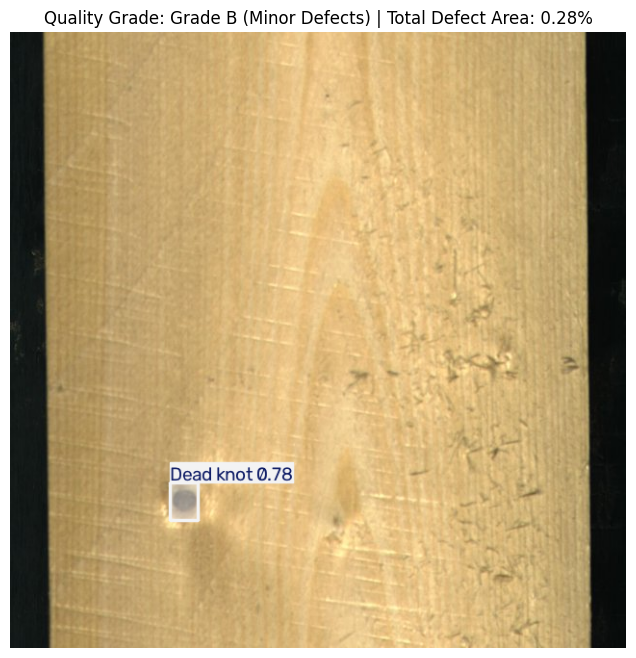

In [13]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 1. Load your best trained segmentation model
model = YOLO("runs/segment/wood_defects/colab_safe_run/weights/best.pt")

def analyze_and_visualize_wood(image_path, conf=0.25):
    """
    Evaluates wood board:
    1. Visualizes segmentation masks and class labels.
    2. Calculates defect coverage area and severity grade.
    """
    image = cv2.imread(image_path)
    if image is None:
        raise FileNotFoundError(f"Could not load image at {image_path}")

    img_height, img_width, _ = image.shape
    total_surface_area = img_height * img_width

    # Run Inference
    results = model(image_path, conf=conf)[0]

    defect_summary = []
    total_defect_pixels = 0

    # Extract detected defects and masks
    if results.masks is not None:
        masks = results.masks.data.cpu().numpy()
        boxes = results.boxes

        for mask, box in zip(masks, boxes):
            # Classification
            class_id = int(box.cls[0].item())
            class_name = model.names[class_id]
            confidence = float(box.conf[0].item())

            # Segmentation Area Calculation
            resized_mask = cv2.resize(mask, (img_width, img_height))
            defect_area_pixels = np.sum(resized_mask > 0.5)
            total_defect_pixels += defect_area_pixels

            # Individual Defect Severity (% of wood board)
            defect_severity_pct = (defect_area_pixels / total_surface_area) * 100

            defect_summary.append({
                "Defect Type": class_name,
                "Confidence": round(confidence, 2),
                "Area (Pixels)": int(defect_area_pixels),
                "Defect Severity": f"{round(defect_severity_pct, 2)}%"
            })

    # Overall Board Severity & Grading
    overall_severity_pct = (total_defect_pixels / total_surface_area) * 100

    if overall_severity_pct == 0:
        grade = "Grade A (Clean)"
    elif overall_severity_pct < 2.0:
        grade = "Grade B (Minor Defects)"
    else:
        grade = "Grade C (Severe Defects / Reject)"

    # Print Text Metrics
    print("=" * 45)
    print(f"OVERALL BOARD SEVERITY: {round(overall_severity_pct, 2)}%")
    print(f"QUALITY GRADE:          {grade}")
    print("=" * 45)
    for idx, defect in enumerate(defect_summary, 1):
        print(f"Defect #{idx}: {defect}")
    print("=" * 45)

    # Render Visual Image with Masks & Bounding Boxes
    annotated_frame = results.plot()
    annotated_frame_rgb = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 8))
    plt.imshow(annotated_frame_rgb)
    plt.axis("off")
    plt.title(f"Quality Grade: {grade} | Total Defect Area: {round(overall_severity_pct, 2)}%")
    plt.show()

# 2. Select a sample image from the test set
test_dir = f"{dataset.location}/test/images"
sample_img = os.path.join(test_dir, os.listdir(test_dir)[0])

# 3. Run Analysis
analyze_and_visualize_wood(sample_img)


Analyzing: 165400015_jpg.rf.ce97a48e1b7e437a4a91c0f48e424ee3.jpg

image 1/1 /content/Wood-defect-detection-1/test/images/165400015_jpg.rf.ce97a48e1b7e437a4a91c0f48e424ee3.jpg: 640x640 1 Dead knot, 1 Live knot, 20.2ms
Speed: 1.2ms preprocess, 20.2ms inference, 2.4ms postprocess per image at shape (1, 3, 640, 640)
OVERALL BOARD SEVERITY: 2.18%
QUALITY GRADE:          Grade C (Severe Defects / Reject)
Defect #1: {'Defect Type': 'Dead knot', 'Confidence': 0.78, 'Area (Pixels)': 4030, 'Defect Severity': '0.98%'}
Defect #2: {'Defect Type': 'Live knot', 'Confidence': 0.56, 'Area (Pixels)': 4914, 'Defect Severity': '1.2%'}


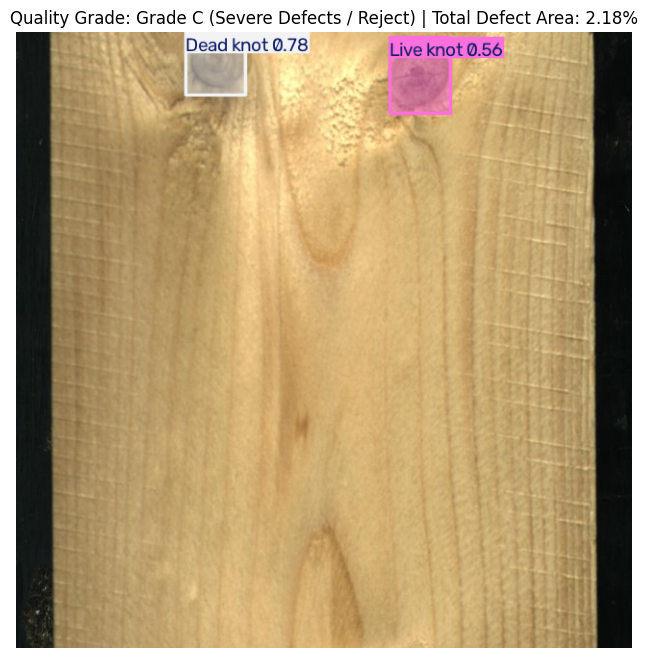


Analyzing: 109800006_jpg.rf.23880a7ba9d2efb864fbccbcae9bfa1d.jpg

image 1/1 /content/Wood-defect-detection-1/test/images/109800006_jpg.rf.23880a7ba9d2efb864fbccbcae9bfa1d.jpg: 640x640 1 Dead knot, 1 Live knot, 20.9ms
Speed: 1.4ms preprocess, 20.9ms inference, 2.6ms postprocess per image at shape (1, 3, 640, 640)
OVERALL BOARD SEVERITY: 0.44%
QUALITY GRADE:          Grade B (Minor Defects)
Defect #1: {'Defect Type': 'Dead knot', 'Confidence': 0.75, 'Area (Pixels)': 690, 'Defect Severity': '0.17%'}
Defect #2: {'Defect Type': 'Live knot', 'Confidence': 0.6, 'Area (Pixels)': 1118, 'Defect Severity': '0.27%'}


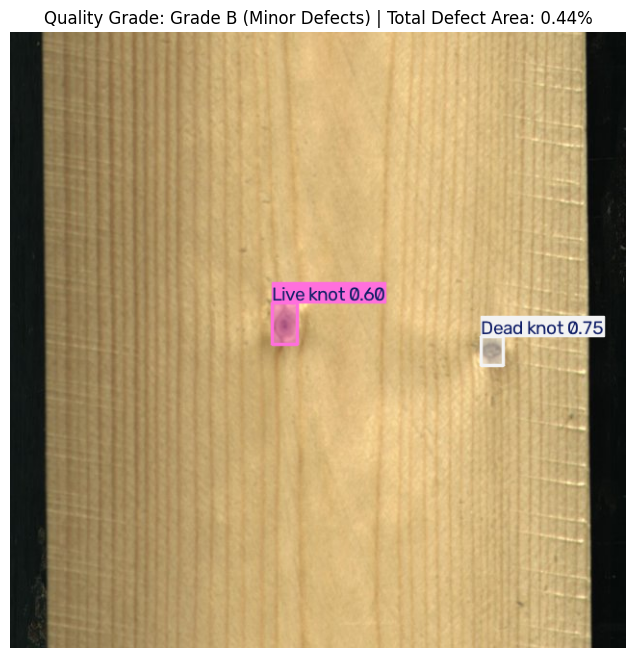


Analyzing: 152700057_jpg.rf.a765cb7744b7672eeb2d550983e975be.jpg

image 1/1 /content/Wood-defect-detection-1/test/images/152700057_jpg.rf.a765cb7744b7672eeb2d550983e975be.jpg: 640x640 1 Dead knot, 2 Live knots, 20.6ms
Speed: 1.1ms preprocess, 20.6ms inference, 3.1ms postprocess per image at shape (1, 3, 640, 640)
OVERALL BOARD SEVERITY: 0.37%
QUALITY GRADE:          Grade B (Minor Defects)
Defect #1: {'Defect Type': 'Dead knot', 'Confidence': 0.55, 'Area (Pixels)': 465, 'Defect Severity': '0.11%'}
Defect #2: {'Defect Type': 'Live knot', 'Confidence': 0.44, 'Area (Pixels)': 434, 'Defect Severity': '0.11%'}
Defect #3: {'Defect Type': 'Live knot', 'Confidence': 0.3, 'Area (Pixels)': 627, 'Defect Severity': '0.15%'}


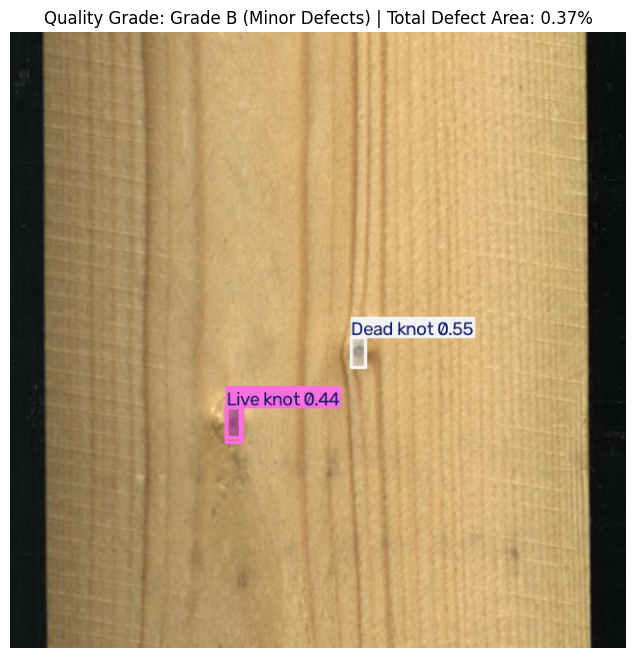


Analyzing: 119100058_jpg.rf.a3a02ff9ad59878bebf513f89806e250.jpg

image 1/1 /content/Wood-defect-detection-1/test/images/119100058_jpg.rf.a3a02ff9ad59878bebf513f89806e250.jpg: 640x640 3 Live knots, 29.9ms
Speed: 3.4ms preprocess, 29.9ms inference, 3.5ms postprocess per image at shape (1, 3, 640, 640)
OVERALL BOARD SEVERITY: 3.0%
QUALITY GRADE:          Grade C (Severe Defects / Reject)
Defect #1: {'Defect Type': 'Live knot', 'Confidence': 0.74, 'Area (Pixels)': 4690, 'Defect Severity': '1.15%'}
Defect #2: {'Defect Type': 'Live knot', 'Confidence': 0.67, 'Area (Pixels)': 5658, 'Defect Severity': '1.38%'}
Defect #3: {'Defect Type': 'Live knot', 'Confidence': 0.65, 'Area (Pixels)': 1938, 'Defect Severity': '0.47%'}


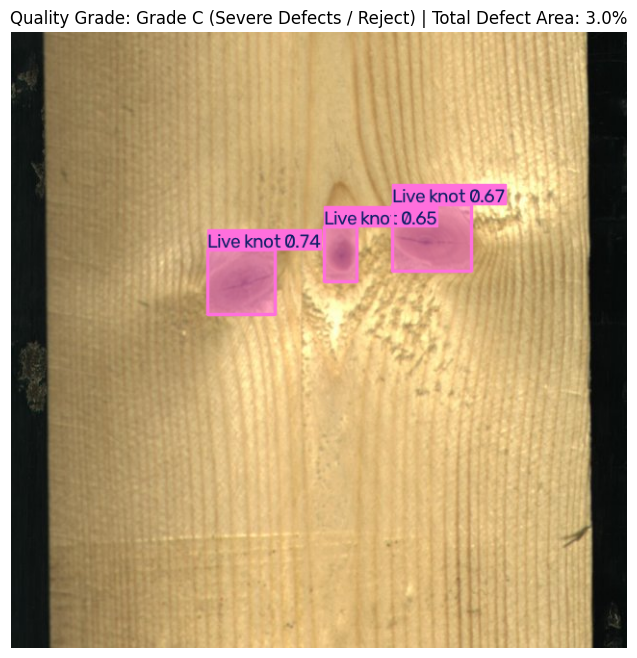


Analyzing: 154000024_jpg.rf.39e55f82b3c30a65844aa99106ab8832.jpg

image 1/1 /content/Wood-defect-detection-1/test/images/154000024_jpg.rf.39e55f82b3c30a65844aa99106ab8832.jpg: 640x640 1 Dead knot, 2 Live knots, 20.3ms
Speed: 1.2ms preprocess, 20.3ms inference, 2.7ms postprocess per image at shape (1, 3, 640, 640)
OVERALL BOARD SEVERITY: 0.52%
QUALITY GRADE:          Grade B (Minor Defects)
Defect #1: {'Defect Type': 'Dead knot', 'Confidence': 0.57, 'Area (Pixels)': 432, 'Defect Severity': '0.11%'}
Defect #2: {'Defect Type': 'Live knot', 'Confidence': 0.48, 'Area (Pixels)': 880, 'Defect Severity': '0.21%'}
Defect #3: {'Defect Type': 'Live knot', 'Confidence': 0.37, 'Area (Pixels)': 798, 'Defect Severity': '0.19%'}


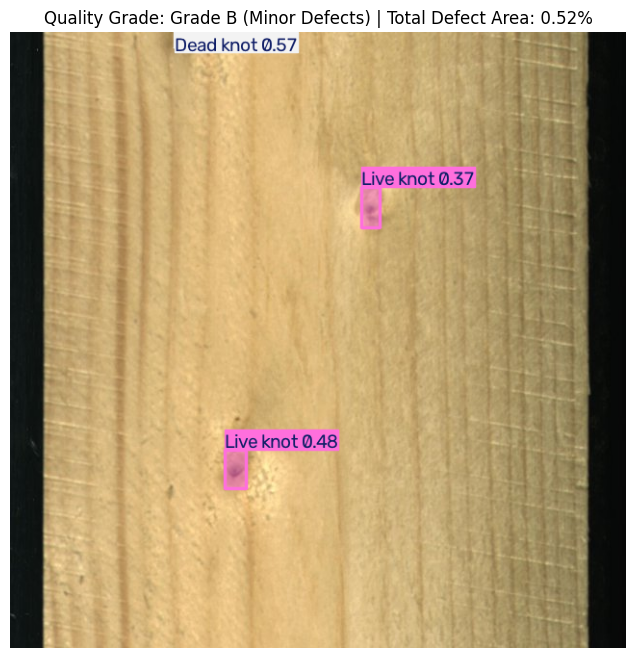

In [14]:
import os
import random


test_dir = f"{dataset.location}/test/images"
all_test_images = [os.path.join(test_dir, f) for f in os.listdir(test_dir) if f.endswith(('.jpg', '.png'))]


random_samples = random.sample(all_test_images, 5)

for img_path in random_samples:
    print(f"\nAnalyzing: {os.path.basename(img_path)}")
    analyze_and_visualize_wood(img_path, conf=0.20)  # Lower confidence threshold catches subtle defects